# Movie Recommendation System (NCF vs Classical Baselines)

В данном проекте реализована и исследована рекомендательная система фильмов на основе датасета MovieLens (около 1M взаимодействий):

- 6,040 пользователей
- ~3,900 фильмов
- 1,000,209 рейтингов

Цель проекта - построить и сравнить современные подходы к Collaborative Filtering, включая классические baseline модели и нейросетевую архитектуру Neural Collaborative Filtering (NCF).

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

In [32]:
movies = pd.read_csv(
    "movies.dat", sep="::", engine="python", header=None, encoding="latin-1"
)
movies.columns = ["MovieID", "Title", "Genres"]
movies.head(10)

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children's
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [33]:
users = pd.read_csv("users.dat", sep="::", engine="python", header=None)
users.columns = ["UserID", "Gender", "Age", "Occupation", "Zip-code"]
users.head(10)

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
5,6,F,50,9,55117
6,7,M,35,1,06810
7,8,M,25,12,11413
8,9,M,25,17,61614
9,10,F,35,1,95370


In [34]:
ratings = pd.read_csv("ratings.dat", sep="::", engine="python", header=None)
ratings.columns = ["UserID", "MovieID", "Rating", "Timestamp"]
ratings.head(10)

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
5,1,1197,3,978302268
6,1,1287,5,978302039
7,1,2804,5,978300719
8,1,594,4,978302268
9,1,919,4,978301368


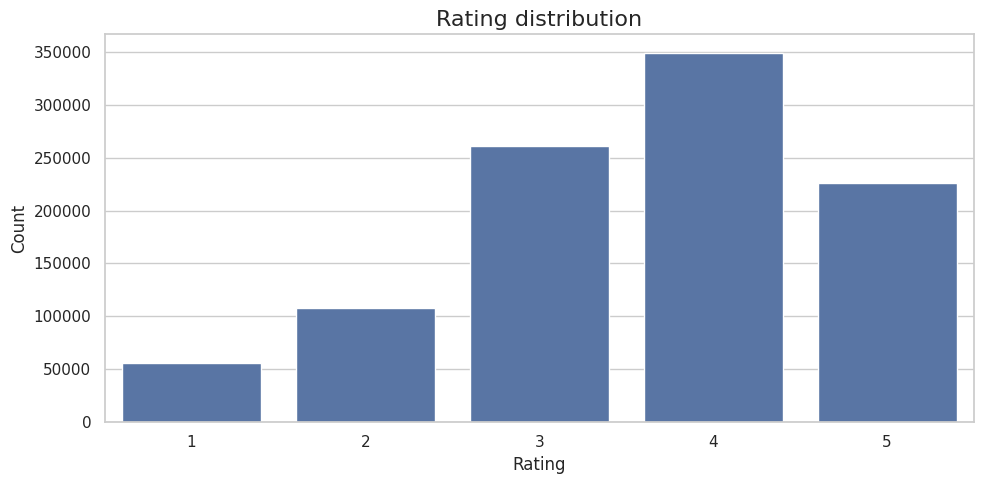

In [35]:
plt.figure()
sns.countplot(x="Rating", data=ratings)
plt.title("Rating distribution", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

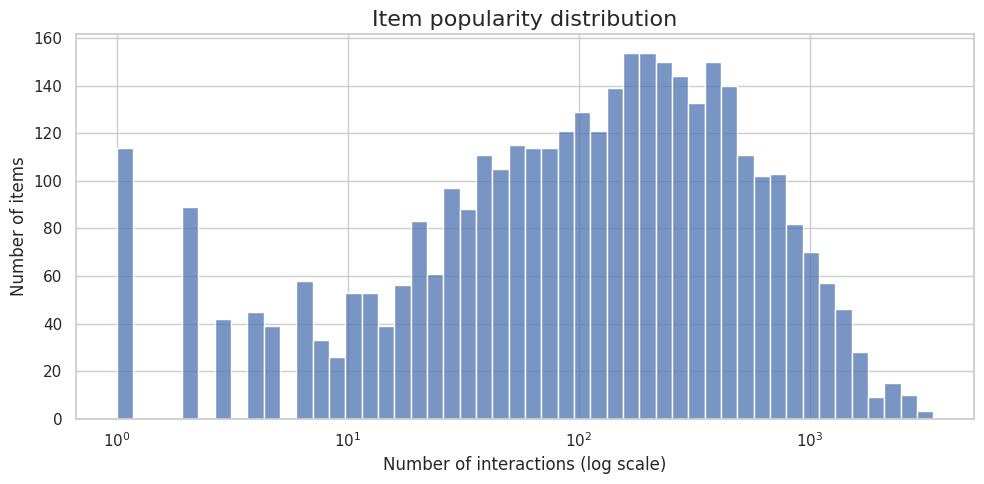

In [37]:
item_counts = ratings.groupby("MovieID").size()
plt.figure()
sns.histplot(item_counts, bins=50, log_scale=True)
plt.title("Item popularity distribution", fontsize=16)
plt.xlabel("Number of interactions (log scale)")
plt.ylabel("Number of items")
plt.tight_layout()
plt.show()

Для выполнения работы я использовала предобработанные данные.

In [38]:
!wget https://raw.githubusercontent.com/hexiangnan/neural_collaborative_filtering/master/Data/ml-1m.test.negative
!wget https://raw.githubusercontent.com/hexiangnan/neural_collaborative_filtering/master/Data/ml-1m.test.rating
!wget https://raw.githubusercontent.com/hexiangnan/neural_collaborative_filtering/master/Data/ml-1m.train.rating

--2026-04-21 22:28:24--  https://raw.githubusercontent.com/hexiangnan/neural_collaborative_filtering/master/Data/ml-1m.test.negative
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2891424 (2.8M) [text/plain]
Saving to: ‘ml-1m.test.negative.1’

ml-1m.test.negative 100%[===================>]   2.76M  16.9MB/s    in 0.2s    

2026-04-21 22:28:25 (16.9 MB/s) - ‘ml-1m.test.negative.1’ saved [2891424/2891424]

--2026-04-21 22:28:25--  https://raw.githubusercontent.com/hexiangnan/neural_collaborative_filtering/master/Data/ml-1m.test.rating
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTT

train.rating: each Line is a training instance: userID itemID rating timestamp (if have)



In [40]:
train_data = pd.read_csv(
    "ml-1m.train.rating",
    sep="\t",
    header=None,
    names=["user", "item", "rating", "timestamp"],
    usecols=[0, 1, 2, 3],
    dtype={0: np.int32, 1: np.int32, 2: np.int32, 3: np.int32},
)
train_data.head()

,user,item,rating,timestamp
0,0,32,4,978824330
1,0,34,4,978824330
2,0,4,5,978824291
3,0,35,4,978824291
4,0,30,4,978824291


In [41]:
user_num = train_data["user"].max() + 1
item_num = train_data["item"].max() + 1

user_num, item_num

(6040, 3706)

Матрица ретингов: строки - пользователи, столбцы - фильмы, на пересечении - 0 (не смотрел фильм) или 1 (смотрел):

In [42]:
import scipy.sparse as sp

train_data = train_data[["user", "item"]].values.tolist()

train_mat = sp.dok_matrix((user_num, item_num), dtype=np.float32)
for x in train_data:
  train_mat[x[0], x[1]] = 1.0


test.rating: test file (positive instances), each Line is a testing instance: userID itemID rating timestamp (if have)

In [43]:
test_data = pd.read_csv(
    "ml-1m.test.rating",
    sep="\t",
    header=None,
    names=["user", "item", "rating", "timestamp"],
    usecols=[0, 1, 2, 3],
    dtype={0: np.int32, 1: np.int32, 2: np.int32, 3: np.int32},
)
test_data.head()

,user,item,rating,timestamp
0,0,25,5,978824351
1,1,133,3,978300174
2,2,207,4,978298504
3,3,208,4,978294282
4,4,222,2,978246585


test.negative: test file (negative instances), each line corresponds to the line of test.rating, containing 99 negative samples. Each line is in the format: (userID,itemID) negativeItemID1 negativeItemID2

Это подготовленный набор данных, который мы будем использовать для тестирования нашей рекомендательной системы. Для каждого пользователя он содержит 1 фильм, который он смотрел, и 99 фильмов, которые он не смотрел. Мы будем использовать их для подсчета метрик качества.

In [44]:
test_data = []
with open("ml-1m.test.negative", "r") as fd:
    line = fd.readline()
    while line != None and line != "":
        arr = line.split("\t")
        u = eval(arr[0])[0]
        test_data.append([u, eval(arr[0])[1]])
        for i in arr[1:]:
            test_data.append([u, int(i)])
        line = fd.readline()

## Подготовка dataloaders
Реализуем специальный класс для работы с данными.

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


In [46]:
class NCFData(data.Dataset):
    def __init__(self, features, num_item, train_mat=None, num_ng=0, is_training=None):
        super(NCFData, self).__init__()
        self.features_ps = features
        self.num_item = num_item
        self.train_mat = train_mat
        self.num_ng = num_ng
        self.is_training = is_training
        self.labels = [0 for _ in range(len(features))]

    def ng_sample(self):
        assert self.is_training, "no need to sampling when testing"

        self.features_ng = []
        for x in self.features_ps:
            u = x[0]
            for t in range(self.num_ng):
                j = np.random.randint(self.num_item)
                while (u, j) in self.train_mat:
                    j = np.random.randint(self.num_item)
                self.features_ng.append([u, j])

        labels_ps = [1 for _ in range(len(self.features_ps))]
        labels_ng = [0 for _ in range(len(self.features_ng))]

        self.features_fill = self.features_ps + self.features_ng
        self.labels_fill = labels_ps + labels_ng

    def __len__(self):
        return (self.num_ng + 1) * len(self.labels)

    def __getitem__(self, idx):

        features = self.features_fill if self.is_training else self.features_ps
        labels = self.labels_fill if self.is_training else self.labels

        user = features[idx][0]
        item = features[idx][1]
        label = labels[idx]
        return user, item, label

In [47]:
train_dataset = NCFData(train_data, item_num, train_mat, num_ng=1, is_training=True)
test_dataset = NCFData(test_data, item_num, train_mat, num_ng=0, is_training=False)
train_dataset.ng_sample()

In [48]:
# создадаем dataloaders для pytorch
train_loader = data.DataLoader(
    train_dataset, batch_size=256, shuffle=True, num_workers=4
)
test_loader = data.DataLoader(
    test_dataset, batch_size=100, shuffle=False, num_workers=0
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Neural Collaborative Filtering

In [49]:
class NCF(nn.Module):
    def __init__(
        self,
        user_num,
        item_num,
        factor_num,
        num_layers,
        dropout,
        model,
        GMF_model=None,
        MLP_model=None,
    ):
        super(NCF, self).__init__()

        self.dropout = dropout
        self.model = model
        self.GMF_model = GMF_model
        self.MLP_model = MLP_model

        self.embed_user_GMF = nn.Embedding(user_num, factor_num)
        self.embed_item_GMF = nn.Embedding(item_num, factor_num)

        self.embed_user_MLP = nn.Embedding(
            user_num, factor_num * (2 ** (num_layers - 1))
        )
        self.embed_item_MLP = nn.Embedding(
            item_num, factor_num * (2 ** (num_layers - 1))
        )

        MLP_modules = []
        for i in range(num_layers):
            input_size = factor_num * (2 ** (num_layers - i))
            MLP_modules.append(nn.Dropout(p=self.dropout))
            MLP_modules.append(nn.Linear(input_size, input_size // 2))
            MLP_modules.append(nn.ReLU())
        self.MLP_layers = nn.Sequential(*MLP_modules)

        if self.model in ["MLP", "GMF"]:
            predict_size = factor_num
        else:
            predict_size = factor_num * 2
        self.predict_layer = nn.Linear(predict_size, 1)

        self._init_weight_()

    def _init_weight_(self):
        if not self.model == "NeuMF-pre":
            nn.init.normal_(self.embed_user_GMF.weight, std=0.01)
            nn.init.normal_(self.embed_user_MLP.weight, std=0.01)
            nn.init.normal_(self.embed_item_GMF.weight, std=0.01)
            nn.init.normal_(self.embed_item_MLP.weight, std=0.01)

            for m in self.MLP_layers:
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight)

            nn.init.kaiming_uniform_(
                self.predict_layer.weight, a=1, nonlinearity="sigmoid"
            )

            for m in self.modules():
                if isinstance(m, nn.Linear) and m.bias is not None:
                    m.bias.data.zero_()
        else:
            self.embed_user_GMF.weight.data.copy_(self.GMF_model.embed_user_GMF.weight)
            self.embed_item_GMF.weight.data.copy_(self.GMF_model.embed_item_GMF.weight)
            self.embed_user_MLP.weight.data.copy_(self.MLP_model.embed_user_MLP.weight)
            self.embed_item_MLP.weight.data.copy_(self.MLP_model.embed_item_MLP.weight)

            for (m1, m2) in zip(self.MLP_layers, self.MLP_model.MLP_layers):
                if isinstance(m1, nn.Linear) and isinstance(m2, nn.Linear):
                    m1.weight.data.copy_(m2.weight)
                    m1.bias.data.copy_(m2.bias)

            predict_weight = torch.cat(
                [
                    self.GMF_model.predict_layer.weight,
                    self.MLP_model.predict_layer.weight,
                ],
                dim=1,
            )

            precit_bias = (
                self.GMF_model.predict_layer.bias + self.MLP_model.predict_layer.bias
            )

            self.predict_layer.weight.data.copy_(0.5 * predict_weight)
            self.predict_layer.bias.data.copy_(0.5 * precit_bias)

    def forward(self, user, item):

        if not self.model == "MLP":
            embed_user_GMF = self.embed_user_GMF(user)
            embed_item_GMF = self.embed_item_GMF(item)
            output_GMF = embed_user_GMF * embed_item_GMF

        if not self.model == "GMF":
            embed_user_MLP = self.embed_user_MLP(user)
            embed_item_MLP = self.embed_item_MLP(item)
            interaction = torch.cat((embed_user_MLP, embed_item_MLP), -1)
            output_MLP = self.MLP_layers(interaction)

        if self.model == "GMF":
            concat = output_GMF
        elif self.model == "MLP":
            concat = output_MLP
        else:
            concat = torch.cat((output_GMF, output_MLP), -1)

        prediction = self.predict_layer(concat)
        return prediction.view(-1)
model = NCF(
    user_num, item_num, factor_num=32, num_layers=3, dropout=0.0, model="NeuMF-end"
)
model.to(DEVICE)

loss_function = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [51]:
model = NCF(
    user_num, item_num, factor_num=32, num_layers=3, dropout=0.0, model="NeuMF-end"
)
model.to(DEVICE)

loss_function = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Обучение модели

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


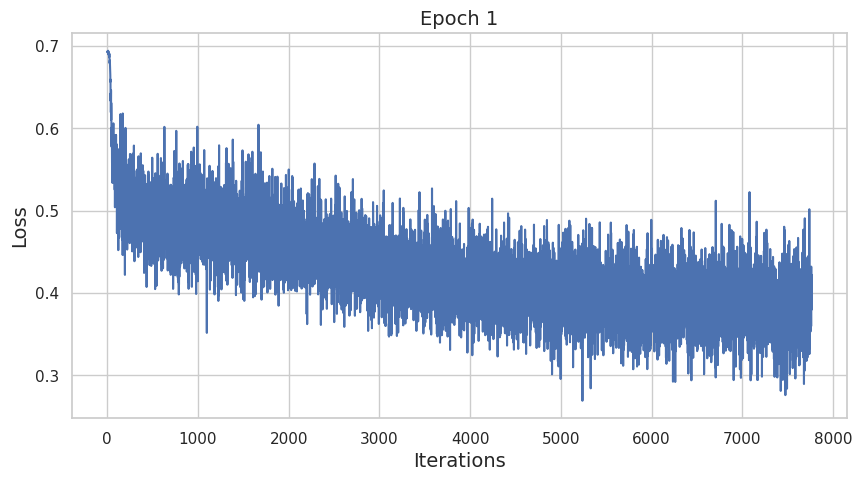

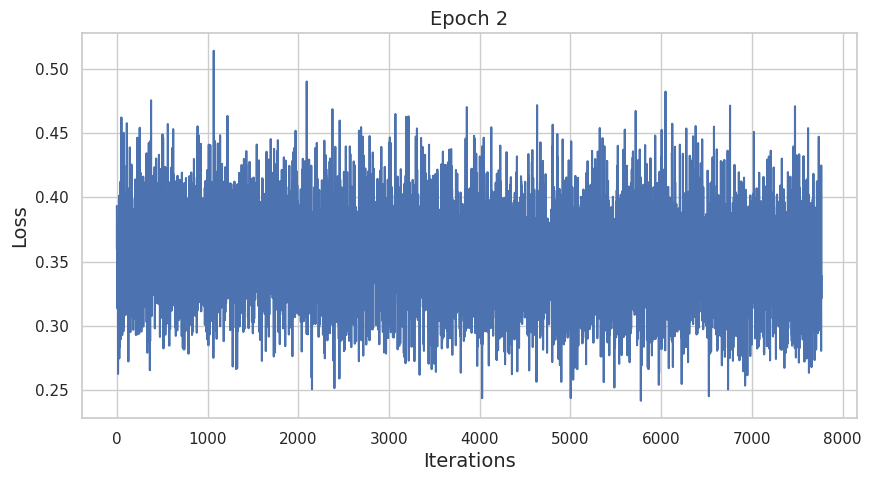

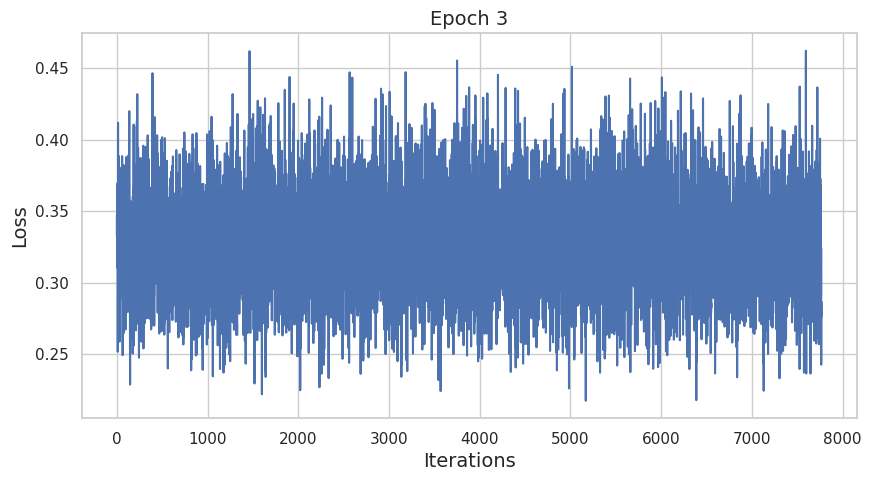

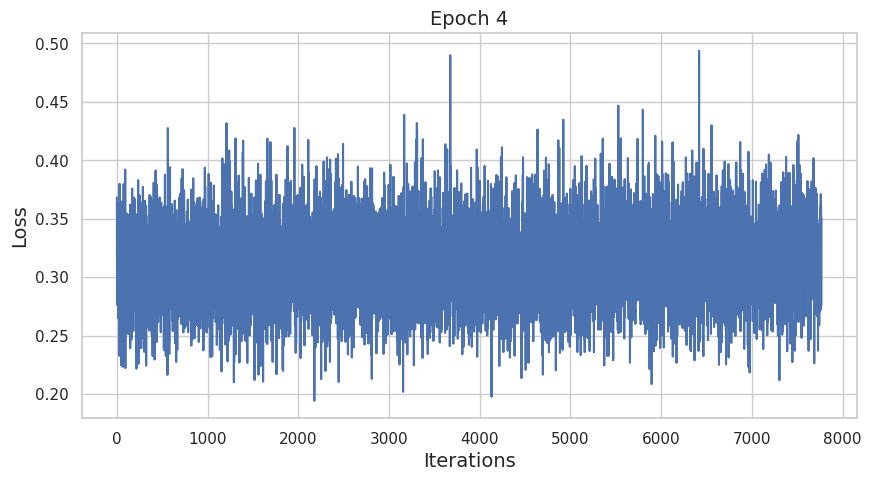

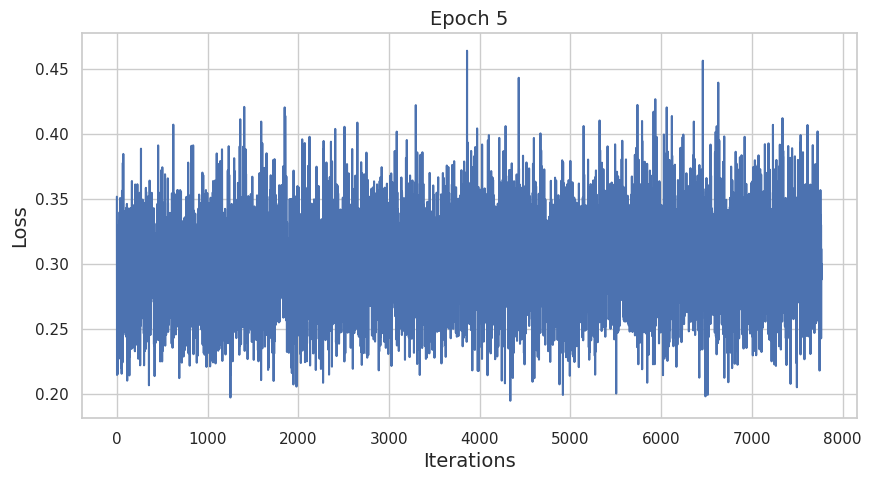

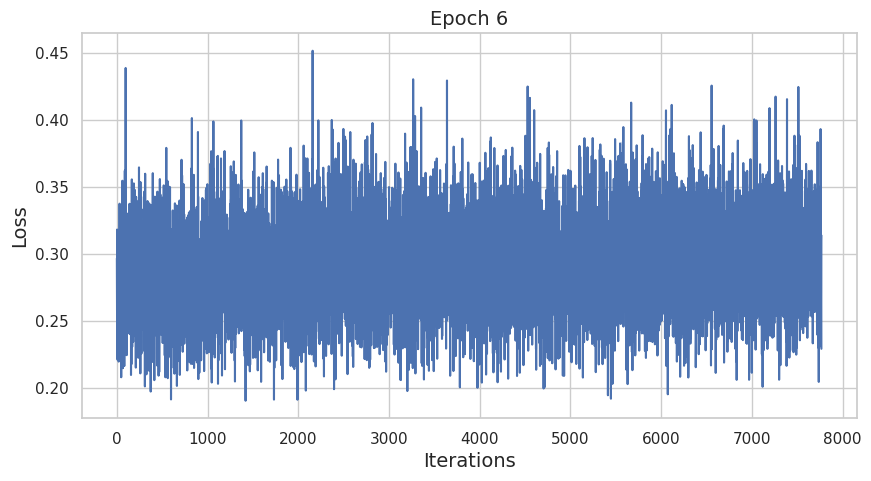

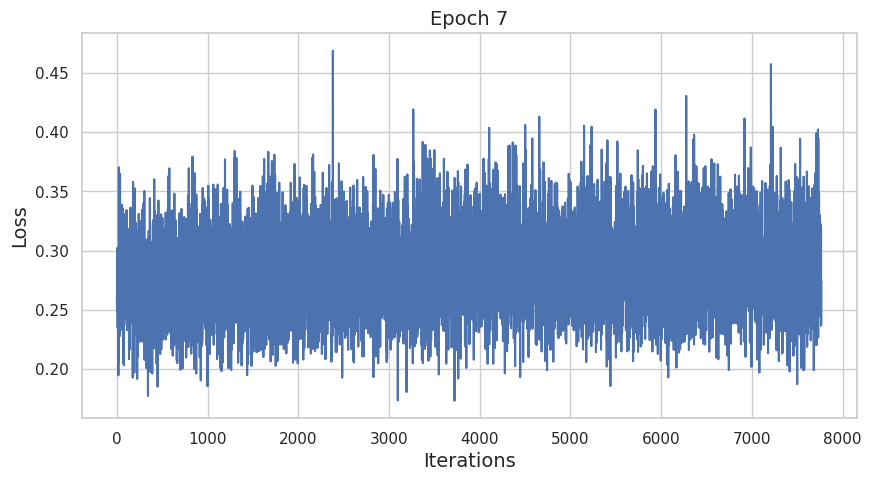

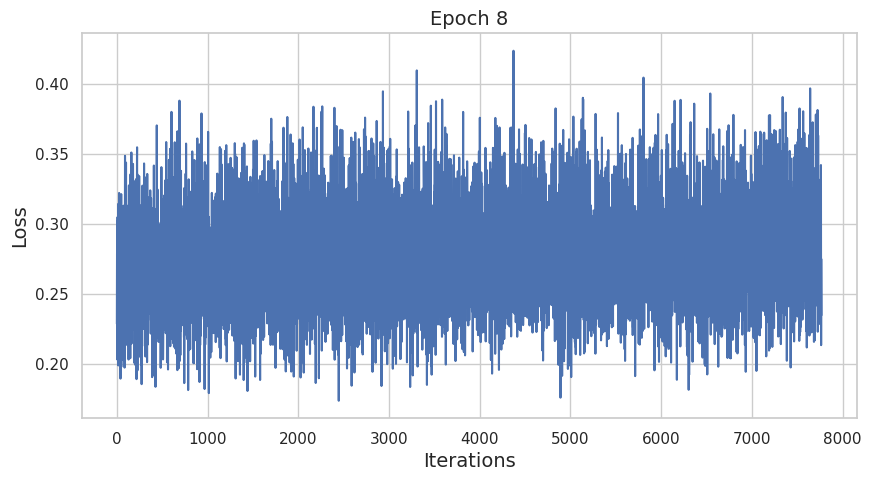

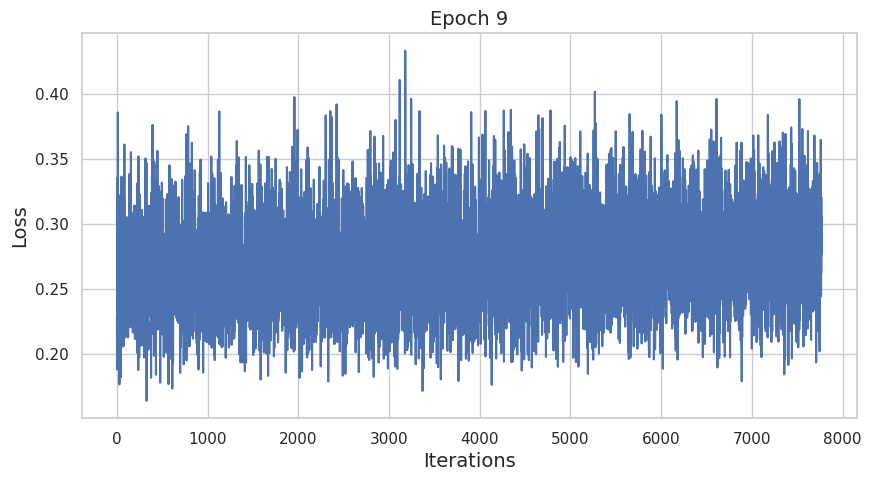

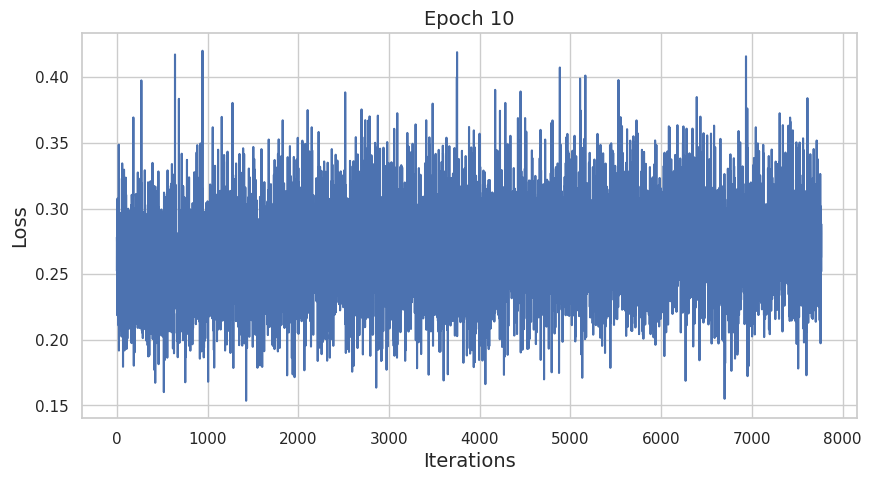

CPU times: user 20min 57s, sys: 42 s, total: 21min 39s
Wall time: 23min 36s


In [52]:
%%time

all_losses = []

for epoch in range(10):

    model.train()
    train_loader.dataset.ng_sample()

    epoch_losses = []
    for user, item, label in train_loader:
        user = user.to(DEVICE)
        item = item.to(DEVICE)
        label = label.float().to(DEVICE)

        model.zero_grad()
        prediction = model(user, item)
        loss = loss_function(prediction, label)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    all_losses.append(epoch_losses)
    plt.figure(figsize=(10, 5))
    plt.plot(epoch_losses)
    plt.xlabel("Iterations", size=14)
    plt.ylabel("Loss", size=14)
    plt.title(f"Epoch {epoch + 1}", size=14)
    plt.show()

### Метрики качества

Подсчет Hitrate@k:

In [54]:
def hit(gt_item, pred_items):
    if gt_item in pred_items:
        return 1
    return 0

Подсчет nDCG@k:

In [55]:
def ndcg(gt_item, pred_items):
    if gt_item in pred_items:
        index = pred_items.index(gt_item)
        return np.reciprocal(np.log2(index + 2))
    return 0

Считаем средние значения метрик качесвта на тестовых данных:

In [56]:
def metrics(model, test_loader, top_k):
    HR, NDCG = [], []

    for user, item, label in test_loader:
        user = user.to(DEVICE)
        item = item.to(DEVICE)

        predictions = model(user, item)
        _, indices = torch.topk(predictions, top_k)
        recommends = torch.take(item, indices).cpu().numpy().tolist()

        gt_item = item[0].item()
        HR.append(hit(gt_item, recommends))
        NDCG.append(ndcg(gt_item, recommends))

    return np.mean(HR), np.mean(NDCG)

Посчитаем метрики качества на тесте:

In [57]:
model.eval()
HR_ncf, NDCG_ncf = metrics(model, test_loader, top_k=10)
HR_ncf, NDCG_ncf

(np.float64(0.6701986754966888), np.float64(0.3965755308612271))

## Factorization machine

In [62]:
from sklearn.feature_extraction import DictVectorizer
import numpy as np

### Подготовка данных

Приведем обучающую выборку к нужному формату:

In [64]:
train_dataset_fm = []
y_train = []

for i in range(0, len(train_dataset.features_fill), 10):
    user, item = train_dataset.features_fill[i]
    label = train_dataset.labels_fill[i]

    train_dataset_fm.append({"user": str(user), "item": str(item)})
    y_train.append(label)

y_train = np.array(y_train)

### Обучение FM

In [65]:
v = DictVectorizer()
X_train = v.fit_transform(train_dataset_fm)

In [69]:
from sklearn.linear_model import SGDClassifier

fm_model = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",
    max_iter=50,
    tol=1e-3
)

fm_model.fit(X_train, y_train)

SGDClassifier(loss='log_loss', max_iter=50)

In [70]:
def predict_fm(model, X):
    return model.decision_function(X)

### Оценка качества

Функция, которая считает средние значения метрик качесвта на тестовых данных:

In [75]:
def metricsFM(model, test_loader, top_k):
    HR, NDCG = [], []

    for user, item, label in test_loader:

        user = user[0].item()
        gt_item = item[0].item()

        candidates = []

        for i in range(item_num):
            candidates.append({"user": str(user), "item": str(i)})

        X = v.transform(candidates)
        scores = model.decision_function(X)

        top_items = np.argsort(-scores)[:top_k]

        top_items = top_items.tolist()

        HR.append(hit(gt_item, top_items))
        NDCG.append(ndcg(gt_item, top_items))

    return np.mean(HR), np.mean(NDCG)

In [76]:
HR_mf, NDCG_mf = metricsFM(fm_model, test_loader, top_k=10)

HR_mf, NDCG_mf

(np.float64(0.02152317880794702), np.float64(0.01050897762117476))